## Roller Coasters Data Analytics Case Study Using Python


### Questions to Answer
Q-1: What are the locations (Top 10) with the fastest roller coasters and what is the mean speed at every location?
Q-2: Top 10 Locations with the most number of steel roller coasters?
Q-3: In the year 2000 at which locations (top 10 locations) most Roller Coasters made of steel were introduced
Q-4: Most Steel Coasters were introduced in which year (Top 10)?
Q-5: Which locations have the most number of operational coasters?
Q-6: What is the mean speed of every type of Roller Coaster?
Q-7: What are the (Top 10) Locations from where most number of coasters were removed?
Q-8: Determine the Percentage of Each Type of Roller Coaster
Q-9: Between the years 1995 and 2005, in each year how many steel and wood coasters were introduced?
Q-9: Between the years 1995 and 2005, in each year how many steel and wood coasters were introduced?
Q-10: How many coasters from each type were removed

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('coaster_db.csv')

In [3]:
df.head()

,coaster_name,Length,Speed,Location,Status,Opening date,Type,Manufacturer,Height restriction,Model,...,speed1,speed2,speed1_value,speed1_unit,speed_mph,height_value,height_unit,height_ft,Inversions_clean,Gforce_clean
0,Switchback Railway,600 ft (180 m),6 mph (9.7 km/h),Coney Island,Removed,"June 16, 1884",Wood,LaMarcus Adna Thompson,NaN,Lift Packed,...,6 mph,9.7 km/h,6.0,mph,6.0,50.0,ft,NaN,0,2.9
1,Flip Flap Railway,NaN,NaN,Sea Lion Park,Removed,1895,Wood,Lina Beecher,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),NaN,NaN,"Cleveland, Ohio, United States",Closed,NaN,Other,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN


In [4]:
df.shape

(1087, 56)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1087 entries, 0 to 1086
Data columns (total 56 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   coaster_name                   1087 non-null   object 
 1   Length                         953 non-null    object 
 2   Speed                          937 non-null    object 
 3   Location                       1087 non-null   object 
 4   Status                         874 non-null    object 
 5   Opening date                   837 non-null    object 
 6   Type                           1087 non-null   object 
 7   Manufacturer                   1028 non-null   object 
 8   Height restriction             831 non-null    object 
 9   Model                          744 non-null    object 
 10  Height                         965 non-null    object 
 11  Inversions                     932 non-null    float64
 12  Lift/launch system             795 non-null    o

In [6]:
# Q-1: What are the locations (Top 10) with the fastest roller coasters and what is the mean speed at every location?

In [7]:
df.groupby('Location')['speed_mph'].mean().sort_values(ascending= False)

Location
Ferrari World Abu Dhabi                                      111.85
Ferrari Land                                                 111.80
Nürburgring                                                   99.40
Primm Valley Resorts                                          80.00
China Dinosaurs Park                                          78.30
                                                              ...  
Tolchester Beach Park                                           NaN
Universal Orlando Resort, Orlando, Florida, United States       NaN
Walygator Parc                                                  NaN
Wet'n'Wild Gold Coast                                           NaN
Wonderland Park (Texas)                                         NaN
Name: speed_mph, Length: 280, dtype: float64

In [8]:
df.groupby('Location')['speed_mph'].mean().sort_values(ascending= False).head(10)

Location
Ferrari World Abu Dhabi    111.850000
Ferrari Land               111.800000
Nürburgring                 99.400000
Primm Valley Resorts        80.000000
China Dinosaurs Park        78.300000
PortAventura Park           77.400000
Holiday Park, Germany       74.600000
Fuji-Q Highland             73.133333
Kolmården Wildlife Park     71.500000
Space World                 71.500000
Name: speed_mph, dtype: float64

<Axes: title={'center': 'fastest roller coaster by location'}, ylabel='Location'>

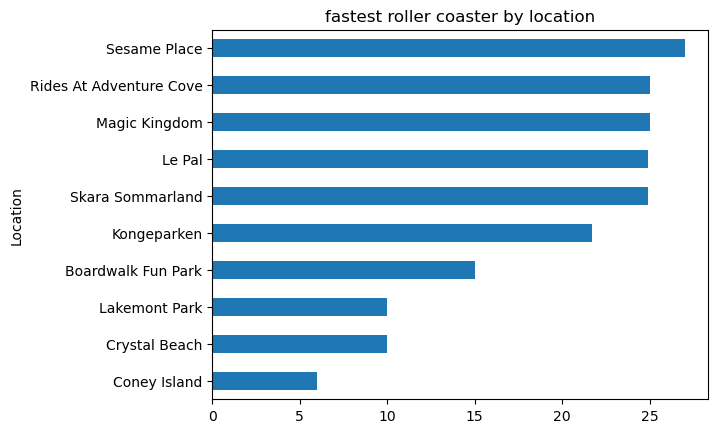

In [27]:
df.groupby('Location')['speed_mph'].mean().sort_values(ascending= True).head(10).plot(
                x='Location', y='speed_mph', kind='barh', 
              title='fastest roller coaster by location')

In [9]:
## Q-2: Top 10 Locations with the most number of steel roller coasters? 

df[df['Type']== 'Steel']['Location'].value_counts().sort_values(ascending = False).head(10)

Location
Other                        59
Six Flags Great Adventure     8
Hersheypark                   7
Six Flags Magic Mountain      7
Cedar Point                   6
Six Flags Over Georgia        6
Six Flags Over Texas          5
Canada's Wonderland           5
Nagashima Spa Land            5
Six Flags Fiesta Texas        4
Name: count, dtype: int64

<Axes: title={'center': 'most number of steel roller coaster'}, ylabel='Location'>

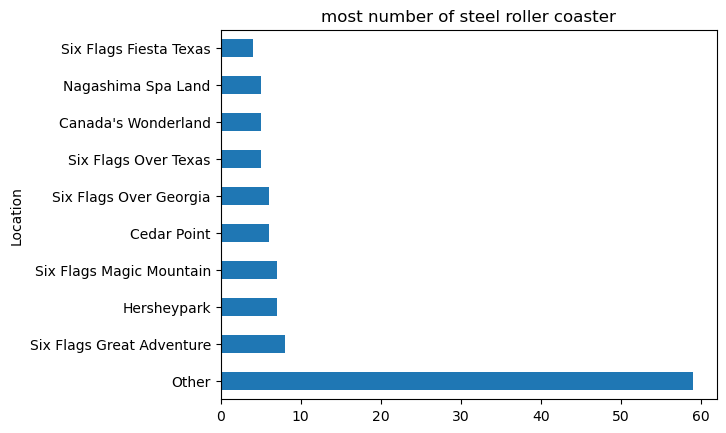

In [30]:
df[df['Type']== 'Steel']['Location'].value_counts().sort_values(ascending = False).head(10).plot(
    x='Type', y='Location', kind='barh', title='most number of steel roller coaster')

In [10]:
##  Q-3: In the year 2000 at which locations (top 10 locations) most Roller Coasters made of steel were introduced

df[df['year_introduced']== 2000]['Location'].value_counts().sort_values(ascending = False).head(10)

Location
Other                    14
Walibi Holland            3
Six Flags New England     2
Six Flags New Orleans     2
Worlds of Fun             1
Six Flags St. Louis       1
Lake Compounce            1
Boomers!                  1
Janfusun Fancyworld       1
Carowinds                 1
Name: count, dtype: int64

In [58]:
 ## Q-4: Most Steel Coasters were introduced in which year (Top 10)? 
    
df[df['Type']=='Steel']['year_introduced'].value_counts().sort_values(ascending = False).head(10)

year_introduced
1999    17
2000    11
1976    10
2018     9
2015     9
2014     9
1989     8
2012     8
2001     8
2008     8
Name: count, dtype: int64

In [60]:
## Q-5: Which locations have the most number of operational coasters?
  
df[df['Status']=='Operating']['Location'].value_counts().sort_values(ascending = False)

Location
Other                       20
Six Flags Magic Mountain    15
Cedar Point                 15
Canada's Wonderland         14
Kings Island                14
                            ..
Tayto Park                   1
ZDT's Amusement Park         1
Paultons Park                1
Clacton Pier                 1
Plopsaland De Panne          1
Name: count, Length: 222, dtype: int64

In [13]:
## Q-6: What is the mean speed of every type of Roller Coaster? 

df.groupby('coaster_name')['speed_mph'].mean().sort_values(ascending = False)

coaster_name
Formula Rossa                                       149.1
Kingda Ka                                           128.0
Top Thrill Dragster                                 120.0
Do-Dodonpa                                          111.8
Red Force (roller coaster)                          111.8
                                                    ...  
Wonder Mountain's Guardian                            NaN
Woodstock's Express (California's Great America)      NaN
Zach's Zoomer                                         NaN
Zip (roller coaster)                                  NaN
Zipper Dipper                                         NaN
Name: speed_mph, Length: 990, dtype: float64

<Axes: xlabel='speed_mph', ylabel='Count'>

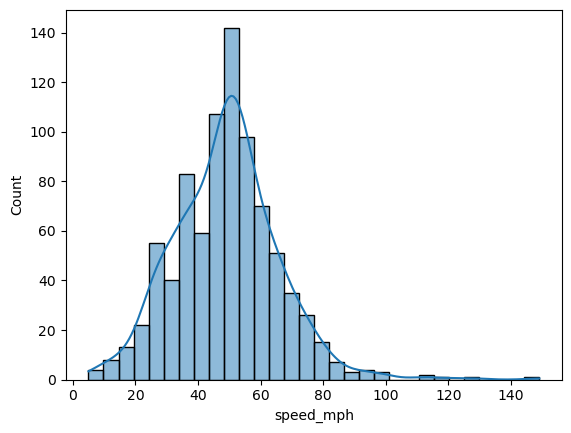

In [52]:
sns.histplot(data = df.groupby('coaster_name')['speed_mph'].mean().sort_values(ascending = False), bins= 30)

In [14]:
##  Q-7: What are the (Top 10) Locations from where most number of coasters were removed?

df[df['Status']== 'Removed']['Location'].value_counts().sort_values(ascending = False).head(10)

Location
Other                        11
Six Flags Great Adventure     6
Coney Island                  6
Kings Island                  5
Revere Beach                  4
Dreamworld                    4
Hersheypark                   4
Geauga Lake                   4
Six Flags AstroWorld          4
Morey's Piers                 3
Name: count, dtype: int64

In [15]:
 ## Q-8: Determine the Percentage of Each Type of Roller Coaster 
import math       
type_count = df['Type'].value_counts()
percentage_type = (type_count/ len(df))*100
print(percentage_type)

Type
Steel                            28.334867
Wood                             15.087397
Other                             6.623735
Steel – Launched                  5.795768
Steel – Inverted                  5.519779
                                   ...    
Wood – Shuttle                    0.091996
Steel junior roller coaster       0.091996
Steel – Euro-Fighter – Indoor     0.091996
Steel – Twister                   0.091996
Steel – Family – Wild Mouse       0.091996
Name: count, Length: 98, dtype: float64


<Axes: title={'center': 'roller coater type percentatge'}, ylabel='count'>

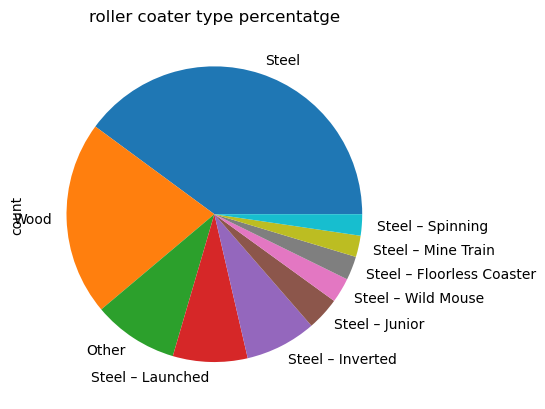

In [32]:
percentage_type.head(10).plot(x='Type', kind='pie', title='roller coater type percentatge')

In [16]:
## Q-9: Between the years 1995 and 2005, in each year how many steel and wood coasters were introduced? 

df_2005 = df[(df['year_introduced']>=1995)&(df['year_introduced']<=2005)]

df_2005[df_2005['Type']=='Steel']['year_introduced'].value_counts().sort_values(ascending = False)


year_introduced
1999    17
2000    11
2001     8
1998     7
2004     7
1995     6
1996     6
2002     6
2003     6
2005     6
1997     4
Name: count, dtype: int64

In [17]:
df_2005[df_2005['Type']=='Wood']['year_introduced'].value_counts().sort_values(ascending = False)

year_introduced
2000    7
1996    6
1999    6
1995    5
1998    5
2001    4
1997    2
2003    2
2004    2
2005    2
2002    1
Name: count, dtype: int64

In [18]:
df_2005[(df_2005['Type']=='Steel')+(df_2005['Type']=='Wood')]['year_introduced'].value_counts().sort_values(ascending = False)

year_introduced
1999    23
2000    18
1996    12
1998    12
2001    12
1995    11
2004     9
2003     8
2005     8
2002     7
1997     6
Name: count, dtype: int64

In [19]:
## Q-10: How many coasters from each type were removed

df[df['Status']== 'Removed']['Type'].value_counts().sort_values(ascending = False)

Type
Steel                            50
Wood                             38
Other                             7
Steel – Suspended                 6
Wood – Racing                     4
Steel – Stand-up                  3
Steel – Launched – Shuttle        3
Steel – Launched                  2
Wood – Out and back               2
Steel – Inverted – Dueling        2
Steel – Enclosed – Bobsled        1
Wood – Shuttle                    1
Wood – Wild Mouse                 1
Steel – Dueling                   1
Steel – Mine Train                1
Steel – Wild Mouse                1
Steel – Kiddie                    1
Steel – Junior                    1
Steel – Enclosed                  1
Steel – Spinning – Wild Mouse     1
Steel – Bobsled                   1
Steel – Shuttle                   1
Steel – Inverted – Launched       1
Steel – Family                    1
– Steel                           1
Steel – Flying                    1
Steel – Wild Mouse – Racing       1
Steel – Wild Mouse – En